# Analysis of Test Coverage

This notebook is using the models we worked on in Simulation Test Coverage.ipnyb

In [1]:
using Revise

In [2]:
using ai_codev_study.Commons
using ai_codev_study.Models

[ Info: Precompiling ai_codev_study [1525f3ab-395e-493d-8c62-d85788d417a1] (cache misses: include_dependency fsize change (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [3]:
using CSV, DataFrames, Turing, Distributions, StatsPlots

In [4]:
data = CSV.read("../../data/tasks_merged.csv", DataFrame)

Row,dev1,task1.ai,task1.codehealth,task1.coverage,task1.measured_time,task1.estimated_time,task1.entry_demo_4,task1.entry_demo_5,task1.entry_ai_1,task1.entry_ai_2,task1.entry_ai_3,task1.entry_ai_4,task1.entry_ai_5,task1.entry_ai_6,task1.entry_ai_7,task1.entry_ai_8,task1.entry_ai_9,task1.entry_ai_10,task1.exit_uninterrupted,task1.exit_space_1,task1.exit_space_2,task1.exit_space_3,task1.exit_space_4,task1.exit_space_5,task1.exit_space_6,task1.exit_space_7,task1.exit_space_8,task1.exit_space_9,task1.exit_space_10,task2.dev2,task2.treatment,task2.codehealth,task2.coverage,task2.measured_time,task2.estimated_time,task2.exit_uninterrupted,task2.exit_space_1,task2.exit_space_2,task2.exit_space_3,task2.exit_space_4,task2.exit_space_5,task2.exit_space_6,task2.exit_space_7,task2.exit_space_8,task2.exit_space_9,task2.exit_space_10,task1.ai_xp,task1.ai_pref
,String7,Bool,Float64,Float64,Int64,Float64?,String15,String15,Bool,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,String15?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,String7,String7,Float64,Float64,Float64,Float64?,String15?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Int64,Float64?
1,anon126,true,8.34,0.74,3290,missing,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,Yes,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon136,ai,8.42,0.73,4773.0,missing,Yes,4.0,4.0,1.0,5.0,5.0,4.0,1.0,2.0,3.0,1.0,5,5.0
2,anon126,true,8.34,0.74,3290,missing,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,Yes,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon106,ai,8.07,0.75,15671.0,missing,Yes,5.0,4.0,3.0,1.0,4.0,5.0,5.0,5.0,5.0,2.0,5,5.0
3,anon126,true,8.34,0.74,3290,missing,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,Yes,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon037,ai,8.43,0.73,6327.0,missing,Yes,5.0,4.0,5.0,4.0,4.0,4.0,4.0,5.0,4.0,4.0,5,5.0
4,anon126,true,8.34,0.74,3290,missing,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,Yes,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon050,ai,8.84,0.9,94967.0,19800.0,No,5.0,5.0,5.0,2.0,5.0,4.0,5.0,5.0,5.0,5.0,5,5.0
5,anon094,true,8.5,0.71,6601,missing,Professional,Advanced,true,5.0,5.0,5.0,5.0,5.0,4.0,1.0,3.0,4.0,"Yes, but breaks",4.0,4.0,5.0,1.0,5.0,5.0,5.0,4.0,4.0,2.0,anon005,ai,8.64,0.71,391708.0,5400.0,Yes,5.0,3.0,4.0,2.0,4.0,3.0,3.0,4.0,5.0,3.0,5,4.5
6,anon126,true,8.88,0.91,462632,10800.0,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,No,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon136,ai,8.42,0.73,4773.0,missing,Yes,4.0,4.0,1.0,5.0,5.0,4.0,1.0,2.0,3.0,1.0,5,5.0
7,anon126,true,8.88,0.91,462632,10800.0,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,No,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon106,ai,8.07,0.75,15671.0,missing,Yes,5.0,4.0,3.0,1.0,4.0,5.0,5.0,5.0,5.0,2.0,5,5.0
8,anon126,true,8.88,0.91,462632,10800.0,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,No,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon037,ai,8.43,0.73,6327.0,missing,Yes,5.0,4.0,5.0,4.0,4.0,4.0,4.0,5.0,4.0,4.0,5,5.0
9,anon126,true,8.88,0.91,462632,10800.0,Professional,Beginner,true,5.0,5.0,5.0,5.0,5.0,5.0,1.0,5.0,5.0,No,5.0,5.0,5.0,1.0,5.0,5.0,5.0,5.0,5.0,1.0,anon050,ai,8.84,0.9,94967.0,19800.0,No,5.0,5.0,5.0,2.0,5.0,4.0,5.0,5.0,5.0,5.0,5,5.0


In [5]:
selected_columns = ["task1.ai",
    "task1.ai_xp",
    "task1.entry_demo_5",
    "task1.coverage",
    "task2.coverage"]

5-element Vector{String}:
 "task1.ai"
 "task1.ai_xp"
 "task1.entry_demo_5"
 "task1.coverage"
 "task2.coverage"

In [6]:
selected_data = data[!,selected_columns]

Row,task1.ai,task1.ai_xp,task1.entry_demo_5,task1.coverage,task2.coverage
,Bool,Int64,String15,Float64,Float64
1,true,5,Beginner,0.74,0.73
2,true,5,Beginner,0.74,0.75
3,true,5,Beginner,0.74,0.73
4,true,5,Beginner,0.74,0.9
5,true,5,Advanced,0.71,0.71
6,true,5,Beginner,0.91,0.73
7,true,5,Beginner,0.91,0.75
8,true,5,Beginner,0.91,0.73
9,true,5,Beginner,0.91,0.9


In [7]:
complete_case = dropmissing(selected_data)

Row,task1.ai,task1.ai_xp,task1.entry_demo_5,task1.coverage,task2.coverage
,Bool,Int64,String15,Float64,Float64
1,true,5,Beginner,0.74,0.73
2,true,5,Beginner,0.74,0.75
3,true,5,Beginner,0.74,0.73
4,true,5,Beginner,0.74,0.9
5,true,5,Advanced,0.71,0.71
6,true,5,Beginner,0.91,0.73
7,true,5,Beginner,0.91,0.75
8,true,5,Beginner,0.91,0.73
9,true,5,Beginner,0.91,0.9


Complete case analysis doesn't drop any rows. Good!

# Models

We'll use Fractional Logistic Regression, which is basically a regression on the logit of the test coverage. Taking the logit re-maps the test coverage on a scale $]0;\infty[$. 

Let's see what is the resulting distribution, if it looks normal-ish, we can use regular regression (even thought the interpretation of coefficients is a bit tricky.)

In [8]:
complete_case[!,"task1.logit_coverage"] = Commons.logit.(complete_case[!,"task1.coverage"])
complete_case[!,"task2.logit_coverage"] = Commons.logit.(complete_case[!,"task2.coverage"])

79-element Vector{Float64}:
 0.9946225751440619
 1.0986122886681098
 0.9946225751440619
 2.1972245773362196
 0.8953840470548413
 0.9946225751440619
 1.0986122886681098
 0.9946225751440619
 2.1972245773362196
 0.9444616088408513
 0.8953840470548413
 0.9444616088408513
 0.8001193001121129
 ⋮
 0.8472978603872034
 0.8001193001121129
 0.708185057924486
 0.6190392084062236
 0.3639653772014115
 0.6632942174102643
 1.0459685551826876
 0.8472978603872034
 0.8001193001121129
 0.9444616088408513
 0.8953840470548413
 0.8953840470548413

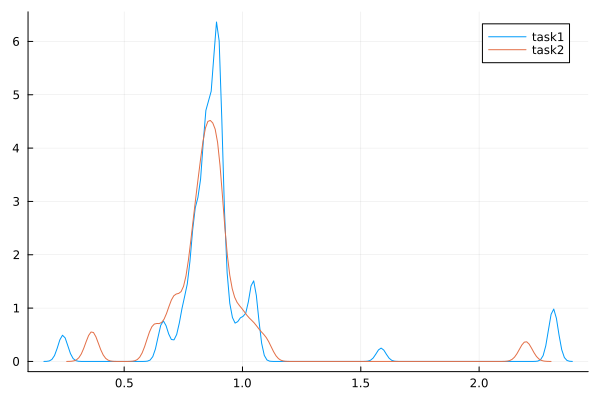

In [9]:
density(complete_case[!,"task1.logit_coverage"], label="task1")
density!(complete_case[!,"task2.logit_coverage"], label="task2")

## Model 1

Considering only `ai_use`. 

In [10]:
model_0 = Models.test_coverage_analysis(
    complete_case[!,"task1.ai"],
    complete_case[!,"task2.logit_coverage"])

DynamicPPL.Model{typeof(ai_codev_study.Models.test_coverage_analysis), (:ai_use, :logit_test_coverage), (), (), Tuple{Vector{Bool}, Vector{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.test_coverage_analysis, (ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], logit_test_coverage = [0.9946225751440619, 1.0986122886681098, 0.9946225751440619, 2.1972245773362196, 0.8953840470548413, 0.9946225751440619, 1.0986122886681098, 0.9946225751440619, 2.1972245773362196, 0.9444616088408513  …  0.708185057924486, 0.6190392084062236, 0.3639653772014115, 0.6632942174102643, 1.0459685551826876, 0.8472978603872034, 0.8001193001121129, 0.9444616088408513, 0.8953840470548413, 0.8953840470548413]), NamedTuple(), DynamicPPL.DefaultContext())

In [11]:
chain_0 = sample(model_0, NUTS(), MCMCSerial(), 2000, 4)

┌ Info: Found initial step size
└   ϵ = 0.025
Sampling (Chain 1 of 4): 100%|██████████████████████████| Time: 0:00:00
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (Chain 2 of 4): 100%|██████████████████████████| Time: 0:00:00
┌ Info: Found initial step size
└   ϵ = 0.4
Sampling (Chain 3 of 4): 100%|██████████████████████████| Time: 0:00:00
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (Chain 4 of 4): 100%|██████████████████████████| Time: 0:00:00


Chains MCMC chain (2000×17×4 Array{Float64, 3}):

Iterations        = 1001:1:3000
Number of chains  = 4
Samples per chain = 2000
Wall duration     = 9.99 seconds
Compute duration  = 7.7 seconds
parameters        = intercept, effect_ai, sigma
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Use `describe(chains)` for summary statistics and quantiles.


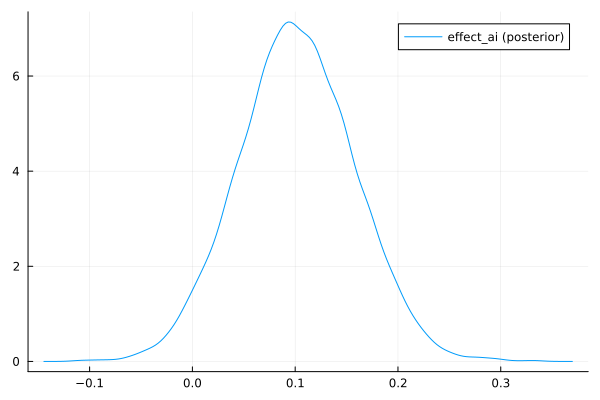

In [12]:
density(chain_0[:effect_ai] |> vec,
    label="effect_ai (posterior)")

We see a mildly positive effect. We will investigate further with simulations, to see what this really means.

In [13]:
Commons.credibility_interval(chain_0[:effect_ai], 0.95)

2-element Vector{Float64}:
 -0.01
  0.21

## Model with controls

We add more controls to see how they affect the estimated effect of AI.

In [14]:
model_1 = Models.test_coverage_analysis_with_controls(
    complete_case[!,"task1.ai"], 
    complete_case[!,"task1.ai_xp"], 
    Commons.dev1_skill_to_indexes(complete_case[!,"task1.entry_demo_5"]),
    complete_case[!,"task2.logit_coverage"])

DynamicPPL.Model{typeof(ai_codev_study.Models.test_coverage_analysis_with_controls), (:ai_use, :ai_xp, :dev1_skill, :logit_test_coverage, :prior_effect_ai), (), (), Tuple{Vector{Bool}, Vector{Int64}, Vector{Union{Nothing, Int64}}, Vector{Float64}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.test_coverage_analysis_with_controls, (ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ai_xp = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5  …  2, 2, 2, 1, 1, 1, 3, 1, 1, 1], dev1_skill = Union{Nothing, Int64}[1, 1, 1, 1, 3, 1, 1, 1, 1, 3  …  2, 3, 3, 2, 3, 3, 2, 3, 3, 3], logit_test_coverage = [0.9946225751440619, 1.0986122886681098, 0.9946225751440619, 2.1972245773362196, 0.8953840470548413, 0.9946225751440619, 1.0986122886681098, 0.9946225751440619, 2.1972245773362196, 0.9444616088408513  …  0.708185057924486, 0.6190392084062236, 0.3639653772014115, 0.6632942174102643, 1.0459685551826876, 0.8472978603872034, 0.8001193001121129, 0.9444616088408513, 0.

In [15]:
chain_1 = sample(model_1, NUTS(), MCMCSerial(), 2000, 4)

┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (Chain 1 of 4): 100%|██████████████████████████| Time: 0:00:03
┌ Info: Found initial step size
└   ϵ = 0.003125
Sampling (Chain 2 of 4): 100%|██████████████████████████| Time: 0:00:02
┌ Info: Found initial step size
└   ϵ = 0.05
Sampling (Chain 3 of 4): 100%|██████████████████████████| Time: 0:00:02
┌ Info: Found initial step size
└   ϵ = 0.025
Sampling (Chain 4 of 4): 100%|██████████████████████████| Time: 0:00:02


Chains MCMC chain (2000×27×4 Array{Float64, 3}):

Iterations        = 1001:1:3000
Number of chains  = 4
Samples per chain = 2000
Wall duration     = 20.82 seconds
Compute duration  = 19.09 seconds
parameters        = intercept, effect_ai, sigma_interactions, effect_ai_xp_z[1], effect_ai_xp_z[2], effect_ai_xp_z[3], effect_ai_xp_z[4], effect_ai_xp_z[5], sigma_effect_skill, effect_dev1_skill_z[1], effect_dev1_skill_z[2], effect_dev1_skill_z[3], logit_sigma
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Use `describe(chains)` for summary statistics and quantiles.


In [16]:
ess_rhat(chain_1)

ESS/R-hat
              parameters         ess      rhat   ess_per_sec 
                  Symbol     Float64   Float64       Float64 

               intercept   1119.9643    1.0046       58.6614
               effect_ai   1343.2356    1.0067       70.3559
      sigma_interactions   2122.1456    1.0019      111.1537
       effect_ai_xp_z[1]   3691.2506    1.0012      193.3402
       effect_ai_xp_z[2]   4726.6940    1.0014      247.5746
       effect_ai_xp_z[3]   3649.7568    1.0012      191.1668
       effect_ai_xp_z[4]   2181.7272    1.0045      114.2744
       effect_ai_xp_z[5]   2768.7950    1.0020      145.0238
      sigma_effect_skill   2035.8784    1.0029      106.6352
  effect_dev1_skill_z[1]   2071.8471    1.0013      108.5191
  effect_dev1_skill_z[2]   1525.6703    1.0017       79.9115
  effect_dev1_skill_z[3]   1512.5557    1.0027       79.2246
             logit_sigma   2960.7525    1.0006      155.0782


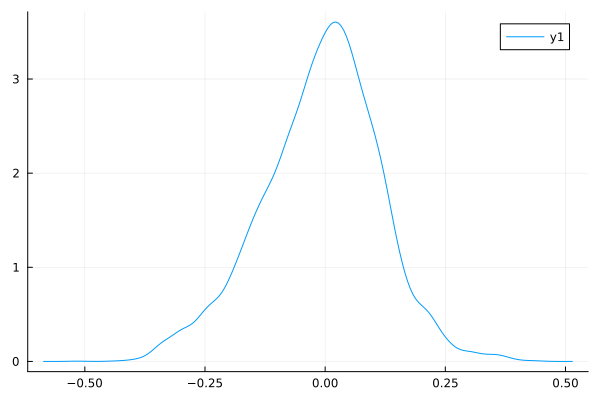

In [17]:
density(chain_1[:effect_ai] |> vec)

In [18]:
Commons.credibility_interval(chain_1[:effect_ai], 0.95)

2-element Vector{Float64}:
 -0.28
  0.22

Based on this, we don't see a significant effect due to using AI. The effect we saw with Model 0 could be due to slight differences in the two population that is not related to AI usage. 

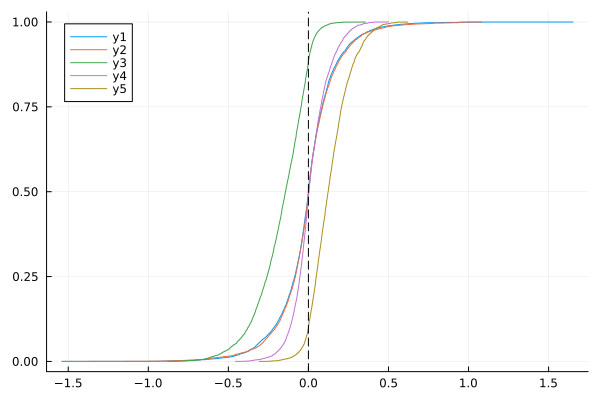

In [19]:
p = plot() 

for ai_xp in 1:5
    ecdfplot!(p, vec(chain_1["effect_ai_xp_z[$ai_xp]"] .* chain_1["sigma_interactions"]))
end

Commons.plotzero!(p)

When we look at the effects of ai_xp, we don't see major differences between them. Perhaps a level 3 is a bit lower than expected, and level 5 a bit higher? 

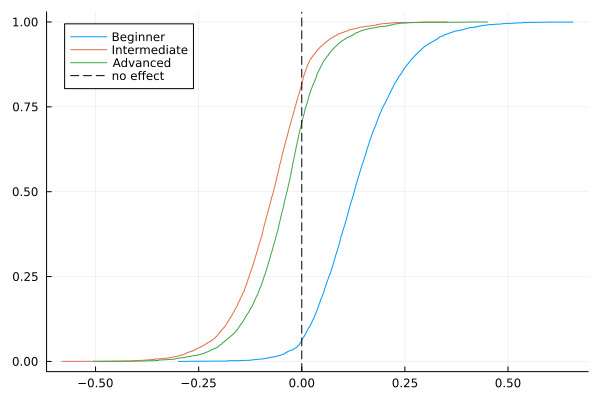

In [20]:
p = plot()


for dev1_skill in 1:3
    
    effect = chain_1["effect_dev1_skill_z[$dev1_skill]"] .* chain_1["sigma_effect_skill"]
    labels = ["Beginner", "Intermediate", "Advanced"]
    
    ecdfplot!(p,effect |> vec, label=labels[dev1_skill])

end

vline!([0], color=:black, style=:dash, label="no effect")

p

As we can see in this plot, on the other hand, that beginner developers tend to care about test coverage more than intermediate and advanced developers. (The cumulative posterior curve is on the right of zero).

In [21]:
combine(groupby(complete_case, ["task1.entry_demo_5", "task1.ai"]), "task2.coverage" => length)

Row,task1.entry_demo_5,task1.ai,task2.coverage_length
,String15,Bool,Int64
1,Beginner,false,1
2,Beginner,true,14
3,Advanced,false,24
4,Advanced,true,14
5,Intermediate,false,10
6,Intermediate,true,16


We see that the cohort using AI had more people who were beginners, while the cohort who didn't, had more developers who were advanced, so it seems that it's the level of the developers which explains the difference, not the use of AI.

# Monotonic Effects

In [22]:
model_2 = Models.test_coverage_analysis_with_controls_2(
    complete_case[!,"task1.ai"], 
    complete_case[!,"task1.ai_xp"], 
    Commons.dev1_skill_to_indexes(complete_case[!,"task1.entry_demo_5"]),
    complete_case[!,"task2.logit_coverage"])

DynamicPPL.Model{typeof(ai_codev_study.Models.test_coverage_analysis_with_controls_2), (:ai_use, :ai_xp, :dev1_skill, :logit_test_coverage, :prior_effect_ai), (), (), Tuple{Vector{Bool}, Vector{Int64}, Vector{Union{Nothing, Int64}}, Vector{Float64}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.test_coverage_analysis_with_controls_2, (ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ai_xp = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5  …  2, 2, 2, 1, 1, 1, 3, 1, 1, 1], dev1_skill = Union{Nothing, Int64}[1, 1, 1, 1, 3, 1, 1, 1, 1, 3  …  2, 3, 3, 2, 3, 3, 2, 3, 3, 3], logit_test_coverage = [0.9946225751440619, 1.0986122886681098, 0.9946225751440619, 2.1972245773362196, 0.8953840470548413, 0.9946225751440619, 1.0986122886681098, 0.9946225751440619, 2.1972245773362196, 0.9444616088408513  …  0.708185057924486, 0.6190392084062236, 0.3639653772014115, 0.6632942174102643, 1.0459685551826876, 0.8472978603872034, 0.8001193001121129, 0.9444616088408513

In [23]:
chain_2 = sample(model_2, NUTS(), MCMCSerial(), 4000, 4)

┌ Info: Found initial step size
└   ϵ = 0.05
Sampling (Chain 1 of 4): 100%|██████████████████████████| Time: 0:00:04
┌ Info: Found initial step size
└   ϵ = 0.05
Sampling (Chain 2 of 4): 100%|██████████████████████████| Time: 0:00:04
┌ Info: Found initial step size
└   ϵ = 0.025
Sampling (Chain 3 of 4): 100%|██████████████████████████| Time: 0:00:04
┌ Info: Found initial step size
└   ϵ = 0.05
Sampling (Chain 4 of 4): 100%|██████████████████████████| Time: 0:00:04


Chains MCMC chain (4000×30×4 Array{Float64, 3}):

Iterations        = 1001:1:5000
Number of chains  = 4
Samples per chain = 4000
Wall duration     = 26.51 seconds
Compute duration  = 24.88 seconds
parameters        = intercept, effect_ai, effect_ai_xp_factor[1], effect_ai_xp_factor[2], effect_ai_xp_factor[3], effect_ai_xp_factor[4], effect_ai_xp_factor[5], effect_skill, effect_skill_factor[1], effect_skill_factor[2], effect_skill_factor[3], effect_dev1_skill[1], effect_dev1_skill[2], effect_dev1_skill[3], effect_skill_difference, logit_sigma
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Use `describe(chains)` for summary statistics and quantiles.


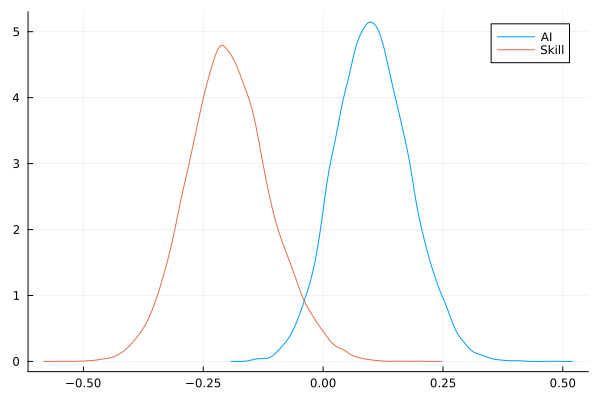

In [69]:
density(chain_2[:effect_ai] |> vec, label="AI")
density!(chain_2[:effect_skill_difference] |> vec, label="Skill")

We don't see a significant effect, even with high AI skill. Interestingly, High skill made people have lower test coverage.

In [74]:
task2_summary = Commons.model_summary(chain_2, direction=(<))

(effect_ai = (p_delta = 0.0844375, mean = 0.1, interval_95 = [-0.04, 0.26]), effect_skill = (p_delta = 0.9835, mean = -0.2, interval_95 = [-0.36, -0.02]))

In [75]:
println("AI")
println(task2_summary[:effect_ai])
println("Skill")
println(task2_summary[:effect_skill])

AI
(p_delta = 0.0844375, mean = 0.1, interval_95 = [-0.04, 0.26])
Skill
(p_delta = 0.9835, mean = -0.2, interval_95 = [-0.36, -0.02])


It seems that: 

1. AI doesn't have much of an effect on Test Coverage
2. Compared to a "beginner", an "advanced" developer will have a tendency to have *less* test coverage.

# Comparison with Task1

In [76]:
model_2_task1 = Models.test_coverage_analysis_with_controls_2(
    complete_case[!,"task1.ai"], 
    complete_case[!,"task1.ai_xp"], 
    Commons.dev1_skill_to_indexes(complete_case[!,"task1.entry_demo_5"]),
    complete_case[!,"task1.logit_coverage"])

DynamicPPL.Model{typeof(ai_codev_study.Models.test_coverage_analysis_with_controls_2), (:ai_use, :ai_xp, :dev1_skill, :logit_test_coverage, :prior_effect_ai), (), (), Tuple{Vector{Bool}, Vector{Int64}, Vector{Union{Nothing, Int64}}, Vector{Float64}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.test_coverage_analysis_with_controls_2, (ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ai_xp = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5  …  2, 2, 2, 1, 1, 1, 3, 1, 1, 1], dev1_skill = Union{Nothing, Int64}[1, 1, 1, 1, 3, 1, 1, 1, 1, 3  …  2, 3, 3, 2, 3, 3, 2, 3, 3, 3], logit_test_coverage = [1.0459685551826876, 1.0459685551826876, 1.0459685551826876, 1.0459685551826876, 0.8953840470548413, 2.313634929180631, 2.313634929180631, 2.313634929180631, 2.313634929180631, 0.8953840470548413  …  0.8472978603872034, 0.24116205681688824, 0.24116205681688824, 0.6632942174102643, 0.8953840470548413, 0.8953840470548413, 0.8472978603872034, 0.8953840470548413,

In [77]:
chain_2_task1 = sample(model_2_task1, NUTS(), MCMCThreads(), 4000, 4) 

┌ Info: Found initial step size
└   ϵ = 0.05
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.2
┌ Info: Found initial step size
└   ϵ = 0.4
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:05


Chains MCMC chain (4000×30×4 Array{Float64, 3}):

Iterations        = 1001:1:5000
Number of chains  = 4
Samples per chain = 4000
Wall duration     = 5.65 seconds
Compute duration  = 21.2 seconds
parameters        = intercept, effect_ai, effect_ai_xp_factor[1], effect_ai_xp_factor[2], effect_ai_xp_factor[3], effect_ai_xp_factor[4], effect_ai_xp_factor[5], effect_skill, effect_skill_factor[1], effect_skill_factor[2], effect_skill_factor[3], effect_dev1_skill[1], effect_dev1_skill[2], effect_dev1_skill[3], effect_skill_difference, logit_sigma
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Use `describe(chains)` for summary statistics and quantiles.


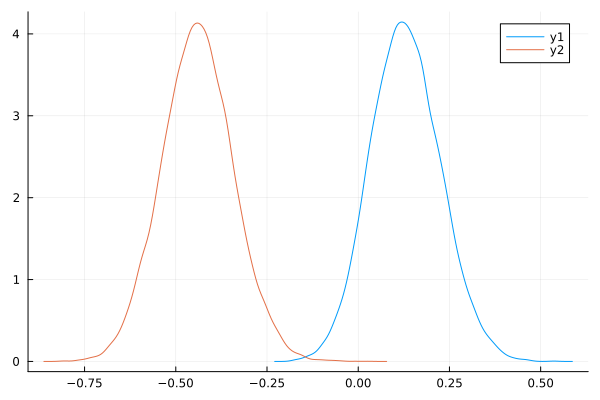

In [93]:
density(vec(chain_2_task1[:effect_ai]))
density!(vec(chain_2_task1[:effect_skill_difference]))

In [94]:
task1_summary = Commons.model_summary(chain_2_task1, direction=(>))

(effect_ai = (p_delta = 0.92, mean = 0.13, interval_95 = [-0.05, 0.32]), effect_skill = (p_delta = 0.0, mean = -0.44, interval_95 = [-0.63, -0.24]))

In [95]:
println("AI")
println(task1_summary[:effect_ai])
println("Skill")
println(task1_summary[:effect_skill])

AI
(p_delta = 0.92, mean = 0.13, interval_95 = [-0.05, 0.32])
Skill
(p_delta = 0.0, mean = -0.44, interval_95 = [-0.63, -0.24])


# Predictions (Task 1)

We'll do a comparison of the predictions because it's easier to understand that "coefficients in log-odds scale". But we need to do it both for task 1 and task 2. 

In [104]:
model_2_task1_predict = Models.test_coverage_analysis_with_controls_2(
    [0, 1], 
    [3, 3], # High AI xp
    [3, 3], # High Java skill
    fill(missing, 2, 1)
    )

DynamicPPL.Model{typeof(ai_codev_study.Models.test_coverage_analysis_with_controls_2), (:ai_use, :ai_xp, :dev1_skill, :logit_test_coverage, :prior_effect_ai), (), (), Tuple{Vector{Int64}, Vector{Int64}, Vector{Int64}, Matrix{Missing}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.test_coverage_analysis_with_controls_2, (ai_use = [0, 1], ai_xp = [3, 3], dev1_skill = [3, 3], logit_test_coverage = [missing; missing;;], prior_effect_ai = Normal{Float64}(μ=0.0, σ=1.0)), NamedTuple(), DynamicPPL.DefaultContext())

In [97]:
predictions_task1 = predict(model_2_task1_predict, chain_2_task1)

Chains MCMC chain (4000×2×4 Array{Float64, 3}):

Iterations        = 1:1:4000
Number of chains  = 4
Samples per chain = 4000
parameters        = logit_test_coverage[1], logit_test_coverage[2]
internals         = 

Use `describe(chains)` for summary statistics and quantiles.


In [98]:
"""
Takes a model with inputs set for two groups, and returns the difference in test_coverage between the two groups
(Focuses on difference between means, so doesn't account the uncertainty in predictions, as this is usually how this thing is reported) 
Return one column for each group.
"""
function extract_diff_test_coverage(model, chain)
    gen = generated_quantities(model, chain) |> m -> reduce(hcat, m)'
    return gen
end

extract_diff_test_coverage

In [99]:
# If we take the predictions as such, we have a lot of noise, so we might want the generated quantities, 
# Which will contain the mean predictions (without noise)
prediction_means = extract_diff_test_coverage(model_2_task1_predict, chain_2_task1)

predictions_tc_with_ai = prediction_means[:,2];
predictions_tc_without_ai = prediction_means[:,1];

In [100]:
# predictions_tc_with_ai = predictions_task1["logit_test_coverage[2]"] |>
#     v -> vec(v) |>
#     v -> Commons.logistic.(v)
# predictions_tc_without_ai = predictions_task1["logit_test_coverage[1]"] |>
#     v -> vec(v) |>
#     v -> Commons.logistic.(v)

In [101]:
Commons.probability_direction(predictions_tc_with_ai, predictions_tc_without_ai, compare=(>))

println(Commons.posterior_summary(predictions_tc_without_ai))
println(Commons.posterior_summary(predictions_tc_with_ai))


(p_delta = 0.0, mean = 0.69, interval_95 = [0.66, 0.71])
(p_delta = 0.0, mean = 0.7, interval_95 = [0.68, 0.72])


In [105]:
Commons.posterior_summary(predictions_tc_with_ai .- predictions_tc_without_ai)

(p_delta = 0.08, mean = 0.01, interval_95 = [-0.01, 0.03])

AI barely improves Test coverage.

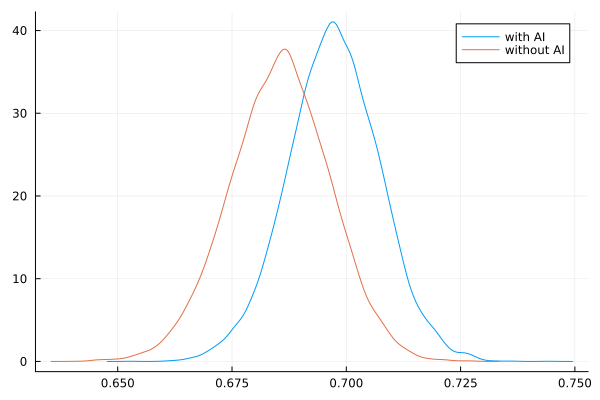

In [106]:
# To look compare the predictions, extract them and plot them? 
density(predictions_tc_with_ai, label="with AI")
density!(predictions_tc_without_ai, label="without AI")

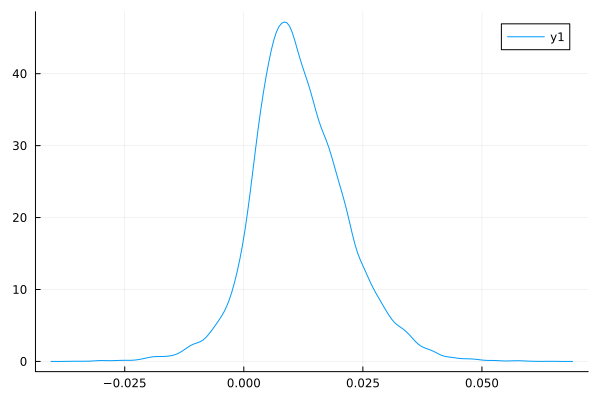

In [107]:
density(predictions_tc_with_ai .- predictions_tc_without_ai)

We see that that with AI, there seems to be a small increase, but not enough for it to be significant.

## Predictions Task 2 (AI vs non-AI)

We plot the predictions for task 2, we expect no effect, since there was no effect for task 1

In [108]:
model_2_predict = Models.test_coverage_analysis_with_controls_2(
    # complete_case[!,"task1.ai"], 
    # Commons.ai_xp_to_indexes(complete_case[!,"task1.ai_xp"]), 
    # Commons.dev1_skill_to_indexes(complete_case[!,"task1.entry_demo_5"]),
    # similar(complete_case[!,"task2.logit_coverage"], Missing))
    [0, 1], 
    [3, 3], 
    [3, 3],
    fill(missing, 1, 2))

DynamicPPL.Model{typeof(ai_codev_study.Models.test_coverage_analysis_with_controls_2), (:ai_use, :ai_xp, :dev1_skill, :logit_test_coverage, :prior_effect_ai), (), (), Tuple{Vector{Int64}, Vector{Int64}, Vector{Int64}, Matrix{Missing}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.test_coverage_analysis_with_controls_2, (ai_use = [0, 1], ai_xp = [3, 3], dev1_skill = [3, 3], logit_test_coverage = [missing missing], prior_effect_ai = Normal{Float64}(μ=0.0, σ=1.0)), NamedTuple(), DynamicPPL.DefaultContext())

In [109]:
predictions_ai = predict(model_2_predict, chain_2)

Chains MCMC chain (4000×2×4 Array{Float64, 3}):

Iterations        = 1:1:4000
Number of chains  = 4
Samples per chain = 4000
parameters        = logit_test_coverage[1], logit_test_coverage[2]
internals         = 

Use `describe(chains)` for summary statistics and quantiles.


In [110]:
# predictions_tc_with_ai_2 = predictions_ai["logit_test_coverage[2]"] |>
#     v -> vec(v) |>
#     v -> Commons.logistic.(v)
# predictions_tc_without_ai_2 = predictions_ai["logit_test_coverage[1]"] |>
#     v -> vec(v) |>
#     v -> Commons.logistic.(v)

In [111]:
# We extract the mean predicted values!
gen_ai_comparison = extract_diff_test_coverage(model_2_predict, chain_2)

16000×2 adjoint(::Matrix{Float64}) with eltype Float64:
 0.668706  0.676543
 0.67514   0.689125
 0.676597  0.689681
 0.68701   0.698142
 0.677724  0.687013
 0.677432  0.684424
 0.677041  0.690421
 0.67744   0.693298
 0.673564  0.696523
 0.688002  0.692994
 0.69681   0.69636
 0.684779  0.700886
 0.681926  0.687465
 ⋮         
 0.700768  0.701919
 0.691726  0.70107
 0.688803  0.700038
 0.6904    0.699517
 0.680773  0.693365
 0.691774  0.711198
 0.672411  0.686086
 0.697871  0.705766
 0.67805   0.684284
 0.696129  0.701056
 0.690514  0.694711
 0.671993  0.69834

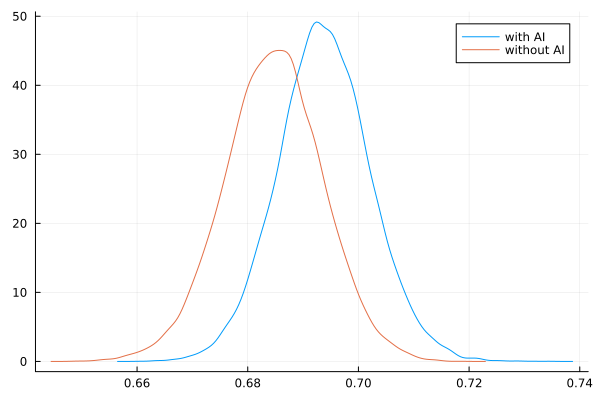

In [112]:
density(gen_ai_comparison[:,2], label="with AI")
density!(gen_ai_comparison[:,1], label="without AI")

In [113]:
println(Commons.posterior_summary(gen_ai_comparison[:,1]))
println(Commons.posterior_summary(gen_ai_comparison[:,2]))

(p_delta = 0.0, mean = 0.68, interval_95 = [0.67, 0.7])
(p_delta = 0.0, mean = 0.69, interval_95 = [0.68, 0.71])


In [114]:
Commons.posterior_summary(gen_ai_comparison[:,2] .- gen_ai_comparison[:,1])

(p_delta = 0.08, mean = 0.01, interval_95 = [-0.01, 0.03])

In [115]:
Commons.probability_direction(gen_ai_comparison[:,1], gen_ai_comparison[:,2], compare=(<))

0.9155625

We don't see much of an effect.

# Predictions for the effect of skill (Task 1)

In [116]:
# Let's see for dev skill
model_2_predict_skill_task1 = Models.test_coverage_analysis_with_controls_2(
    # complete_case[!,"task1.ai"], 
    # Commons.ai_xp_to_indexes(complete_case[!,"task1.ai_xp"]), 
    # Commons.dev1_skill_to_indexes(complete_case[!,"task1.entry_demo_5"]),
    # similar(complete_case[!,"task2.logit_coverage"], Missing))
    [0, 0], 
    [3, 3], 
    [1, 3],
    fill(missing, 1, 2))

DynamicPPL.Model{typeof(ai_codev_study.Models.test_coverage_analysis_with_controls_2), (:ai_use, :ai_xp, :dev1_skill, :logit_test_coverage, :prior_effect_ai), (), (), Tuple{Vector{Int64}, Vector{Int64}, Vector{Int64}, Matrix{Missing}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.test_coverage_analysis_with_controls_2, (ai_use = [0, 0], ai_xp = [3, 3], dev1_skill = [1, 3], logit_test_coverage = [missing missing], prior_effect_ai = Normal{Float64}(μ=0.0, σ=1.0)), NamedTuple(), DynamicPPL.DefaultContext())

In [117]:
gen_task1_skill = extract_diff_test_coverage(model_2_predict_skill_task1, chain_2_task1)

16000×2 adjoint(::Matrix{Float64}) with eltype Float64:
 0.745832  0.692376
 0.774589  0.681701
 0.749687  0.688667
 0.741355  0.678431
 0.751174  0.675593
 0.756877  0.691677
 0.789926  0.686898
 0.752061  0.67095
 0.746537  0.661557
 0.731942  0.672979
 0.738804  0.690138
 0.737382  0.663268
 0.771905  0.697058
 ⋮         
 0.778619  0.678628
 0.804232  0.705027
 0.761623  0.668958
 0.758183  0.681539
 0.790399  0.689296
 0.788838  0.687482
 0.78043   0.685741
 0.796821  0.699005
 0.79262   0.689485
 0.80253   0.691818
 0.760854  0.689529
 0.794911  0.70037

In [118]:
high_skill = gen_task1_skill[:,2]
low_skill = gen_task1_skill[:,1]

16000-element Vector{Float64}:
 0.7458320271311372
 0.7745894095475101
 0.7496870281169766
 0.7413553243585169
 0.7511742391987872
 0.7568774887107552
 0.7899260486772763
 0.7520612899970853
 0.7465368592564888
 0.7319419104877981
 0.7388042600086244
 0.7373819201476014
 0.7719050118297184
 ⋮
 0.7786189657612598
 0.8042321565424253
 0.7616225249176173
 0.758183122935559
 0.7903993637284448
 0.7888382285120287
 0.7804299532320833
 0.7968207766710492
 0.7926201591480172
 0.8025297403878286
 0.7608536496347112
 0.7949105335551645

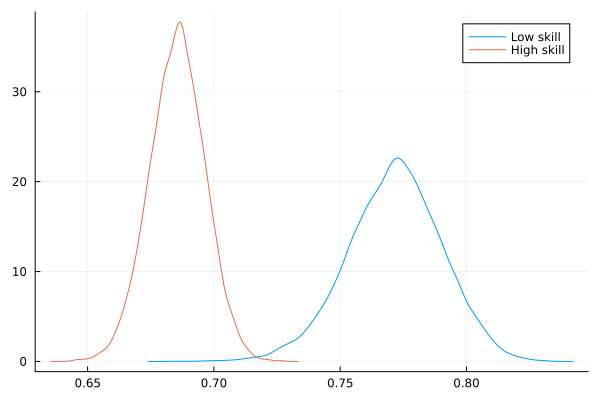

In [119]:
density(low_skill, label="Low skill")
density!(high_skill, label="High skill")

In [120]:
Commons.posterior_summary(high_skill .- low_skill)

(p_delta = 1.0, mean = -0.09, interval_95 = [-0.12, -0.05])

In [121]:
Commons.probability_direction(low_skill, high_skill, compare=(>))

0.9999375

Weirdly enough, highly skill developers had a significantly *lower* test coverage, by approx 10\%. 

## Prediction of the effect of skill (Task 2) 

In [122]:
model_2_predict_skill =  Models.test_coverage_analysis_with_controls_2(
    [0, 0], 
    [3, 3], 
    [1, 3],
    [missing, missing])

DynamicPPL.Model{typeof(ai_codev_study.Models.test_coverage_analysis_with_controls_2), (:ai_use, :ai_xp, :dev1_skill, :logit_test_coverage, :prior_effect_ai), (), (), Tuple{Vector{Int64}, Vector{Int64}, Vector{Int64}, Vector{Missing}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.test_coverage_analysis_with_controls_2, (ai_use = [0, 0], ai_xp = [3, 3], dev1_skill = [1, 3], logit_test_coverage = [missing, missing], prior_effect_ai = Normal{Float64}(μ=0.0, σ=1.0)), NamedTuple(), DynamicPPL.DefaultContext())

In [123]:
predictions_skill = extract_diff_test_coverage(model_2_predict_skill, chain_2)

16000×2 adjoint(::Matrix{Float64}) with eltype Float64:
 0.696919  0.668706
 0.695386  0.67514
 0.739265  0.676597
 0.704052  0.68701
 0.720297  0.677724
 0.708375  0.677432
 0.680263  0.677041
 0.69506   0.67744
 0.685852  0.673564
 0.711183  0.688002
 0.731063  0.69681
 0.71874   0.684779
 0.729825  0.681926
 ⋮         
 0.727492  0.700768
 0.711483  0.691726
 0.695541  0.688803
 0.710365  0.6904
 0.726984  0.680773
 0.697882  0.691774
 0.687862  0.672411
 0.732185  0.697871
 0.739641  0.67805
 0.736055  0.696129
 0.738168  0.690514
 0.700585  0.671993

In [124]:
pred_with_skill = predictions_skill[:,2];
pred_without_skill = predictions_skill[:,1];

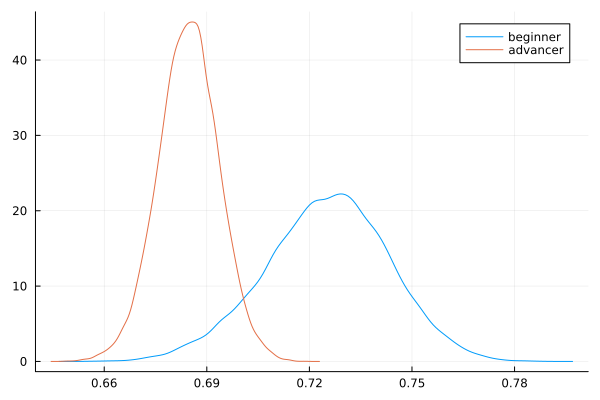

In [125]:
density(pred_without_skill, label="beginner")
density!(pred_with_skill, label="advancer")

In [126]:
Commons.posterior_summary(pred_with_skill .- pred_without_skill)

(p_delta = 0.98, mean = -0.04, interval_95 = [-0.07, -0.0])

Skilled developers have -4 percentage points compared to beginners.

In [127]:
Commons.probability_direction(pred_with_skill .- pred_without_skill)

0.9835

# Sensitivity Analysis

We try with different priors.

In [128]:
complete_case[!,"task1.logit_coverage"] |> std

0.35499493854499703

In [129]:
model_2_optimistic = Models.test_coverage_analysis_with_controls_2(
    complete_case[!,"task1.ai"], 
    complete_case[!,"task1.ai_xp"], 
    Commons.dev1_skill_to_indexes(complete_case[!,"task1.entry_demo_5"]),
    complete_case[!,"task2.logit_coverage"], 
    Normal(0.25, 0.5))

DynamicPPL.Model{typeof(ai_codev_study.Models.test_coverage_analysis_with_controls_2), (:ai_use, :ai_xp, :dev1_skill, :logit_test_coverage, :prior_effect_ai), (), (), Tuple{Vector{Bool}, Vector{Int64}, Vector{Union{Nothing, Int64}}, Vector{Float64}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.test_coverage_analysis_with_controls_2, (ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ai_xp = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5  …  2, 2, 2, 1, 1, 1, 3, 1, 1, 1], dev1_skill = Union{Nothing, Int64}[1, 1, 1, 1, 3, 1, 1, 1, 1, 3  …  2, 3, 3, 2, 3, 3, 2, 3, 3, 3], logit_test_coverage = [0.9946225751440619, 1.0986122886681098, 0.9946225751440619, 2.1972245773362196, 0.8953840470548413, 0.9946225751440619, 1.0986122886681098, 0.9946225751440619, 2.1972245773362196, 0.9444616088408513  …  0.708185057924486, 0.6190392084062236, 0.3639653772014115, 0.6632942174102643, 1.0459685551826876, 0.8472978603872034, 0.8001193001121129, 0.9444616088408513

In [130]:
model_2_pessimistic = Models.test_coverage_analysis_with_controls_2(
    complete_case[!,"task1.ai"], 
    complete_case[!,"task1.ai_xp"], 
    Commons.dev1_skill_to_indexes(complete_case[!,"task1.entry_demo_5"]),
    complete_case[!,"task2.logit_coverage"], 
    Normal(-0.25, 0.5))

DynamicPPL.Model{typeof(ai_codev_study.Models.test_coverage_analysis_with_controls_2), (:ai_use, :ai_xp, :dev1_skill, :logit_test_coverage, :prior_effect_ai), (), (), Tuple{Vector{Bool}, Vector{Int64}, Vector{Union{Nothing, Int64}}, Vector{Float64}, Normal{Float64}}, Tuple{}, DynamicPPL.DefaultContext}(ai_codev_study.Models.test_coverage_analysis_with_controls_2, (ai_use = Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ai_xp = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5  …  2, 2, 2, 1, 1, 1, 3, 1, 1, 1], dev1_skill = Union{Nothing, Int64}[1, 1, 1, 1, 3, 1, 1, 1, 1, 3  …  2, 3, 3, 2, 3, 3, 2, 3, 3, 3], logit_test_coverage = [0.9946225751440619, 1.0986122886681098, 0.9946225751440619, 2.1972245773362196, 0.8953840470548413, 0.9946225751440619, 1.0986122886681098, 0.9946225751440619, 2.1972245773362196, 0.9444616088408513  …  0.708185057924486, 0.6190392084062236, 0.3639653772014115, 0.6632942174102643, 1.0459685551826876, 0.8472978603872034, 0.8001193001121129, 0.9444616088408513

In [131]:
chain_2_optimistic = sample(model_2_optimistic, NUTS(), MCMCSerial(), 2000, 4)

┌ Info: Found initial step size
└   ϵ = 0.05
Sampling (Chain 1 of 4): 100%|██████████████████████████| Time: 0:00:02
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (Chain 2 of 4): 100%|██████████████████████████| Time: 0:00:02
┌ Info: Found initial step size
└   ϵ = 0.4
Sampling (Chain 3 of 4): 100%|██████████████████████████| Time: 0:00:03
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (Chain 4 of 4): 100%|██████████████████████████| Time: 0:00:02


Chains MCMC chain (2000×30×4 Array{Float64, 3}):

Iterations        = 1001:1:3000
Number of chains  = 4
Samples per chain = 2000
Wall duration     = 11.38 seconds
Compute duration  = 11.18 seconds
parameters        = intercept, effect_ai, effect_ai_xp_factor[1], effect_ai_xp_factor[2], effect_ai_xp_factor[3], effect_ai_xp_factor[4], effect_ai_xp_factor[5], effect_skill, effect_skill_factor[1], effect_skill_factor[2], effect_skill_factor[3], effect_dev1_skill[1], effect_dev1_skill[2], effect_dev1_skill[3], effect_skill_difference, logit_sigma
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Use `describe(chains)` for summary statistics and quantiles.


In [132]:
chain_2_pessimistic = sample(model_2_pessimistic, NUTS(), MCMCSerial(), 2000, 4)

┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (Chain 1 of 4): 100%|██████████████████████████| Time: 0:00:02
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (Chain 2 of 4): 100%|██████████████████████████| Time: 0:00:02
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (Chain 3 of 4): 100%|██████████████████████████| Time: 0:00:02
┌ Info: Found initial step size
└   ϵ = 0.2
Sampling (Chain 4 of 4): 100%|██████████████████████████| Time: 0:00:02


Chains MCMC chain (2000×30×4 Array{Float64, 3}):

Iterations        = 1001:1:3000
Number of chains  = 4
Samples per chain = 2000
Wall duration     = 11.9 seconds
Compute duration  = 11.69 seconds
parameters        = intercept, effect_ai, effect_ai_xp_factor[1], effect_ai_xp_factor[2], effect_ai_xp_factor[3], effect_ai_xp_factor[4], effect_ai_xp_factor[5], effect_skill, effect_skill_factor[1], effect_skill_factor[2], effect_skill_factor[3], effect_dev1_skill[1], effect_dev1_skill[2], effect_dev1_skill[3], effect_skill_difference, logit_sigma
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Use `describe(chains)` for summary statistics and quantiles.


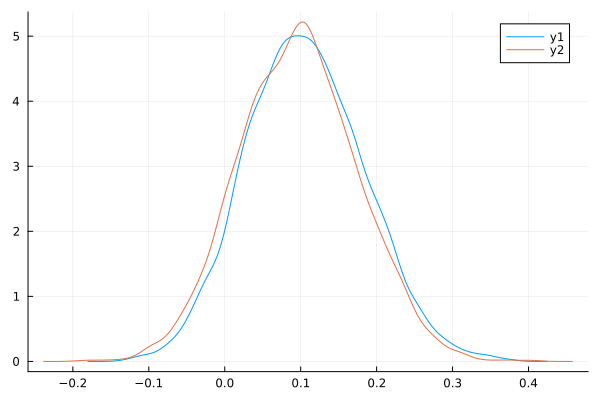

In [133]:
density(chain_2_optimistic[:effect_ai] |> vec)
density!(chain_2_pessimistic[:effect_ai] |> vec)

We don't see much of a difference in effects.